# Analysing Infomap and Neuromap results for WikiCS


In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import json
import os
from pathlib import Path

sys.path.append("..") # go to parent folder
import src.map_equation as meq
import src.optimize as opt
from src.utils import load_wikics_graph, compare_partitions

### Loading the files

In [2]:
VARIANTS = ["directed", "undirected"]
INFOMAP_METHODS = ["custom", "igraph", "infomap_pkg"]
NEUROMAP_ARCHS = ["GCN", "GAT", "GIN", "GraphSAGE"]

NEUROMAP_COLORS = {
    "GCN": "#9d0208",
    "GAT": "#d00000",
    "GIN": "#e85d04",
    "GraphSAGE": "#faa307",
}

INFOMAP_COLORS = {
    "custom": "#1b4965",
    "igraph": "#5fa8d3",
    "infomap_pkg": "#bee9e8",
}


METHODS = ["custom", "igraph", "infomap_pkg", "GCN", "GAT", "GIN", "GraphSAGE"]
COLORS = {
    "custom": "#1b4965",
    "igraph": "#5fa8d3",
    "infomap_pkg": "#bee9e8",
    "GCN": "#9d0208",
    "GAT": "#d00000",
    "GIN": "#e85d04",
    "GraphSAGE": "#faa307",
}


INFOMAP_ROOT = "../results/infomap"
NEUROMAP_ROOT = "../results/neuromap"
NUM_TRIALS = 10

G_directed = load_wikics_graph(directed=True)
G_undirected = load_wikics_graph(directed=False)

In [3]:
def load_json(path: str) -> dict | None:
    if not os.path.exists(path):
        print(f"  [warn] missing file, skipping: {path}")
        return None
    with open(path, "r") as f:
        return json.load(f)

##################################################
# INFOMAP HELPERS
##################################################
    
def load_infomap_aggregated() -> pd.DataFrame:
    """
    One row per (variant, method, trial), with thecodelength, runtime,
    number of communities found .
    """
    rows = []
    for variant in VARIANTS:
        # unfortunately we need the graph for recomputing the codelength
        G = G_directed if variant=="directed" else G_undirected

        for method in INFOMAP_METHODS:
            for trial in range(NUM_TRIALS):
                path = f"{INFOMAP_ROOT}/{variant}/{method}_trial{trial}.json"
                data = load_json(path)
                if data is None:
                    continue

                # recompute the codelength for comparability:
                comms = data["communities"]
                codelength_recomputed = meq.compute_description_length(G, comms)

                rows.append({"variant": variant,
                            "method": method,
                            "trial": trial,
                            "codelength": data["codelength"],
                            "codelength_recomputed": codelength_recomputed,
                            "runtime_seconds": data["runtime_seconds"],
                            "num_communities": data["num_communities"]
                            })
    return pd.DataFrame(rows)


def load_infomap_comms() -> dict[tuple[str, str], list[int]]:
    """Returns {(variant, method): communities} for the best partition of
    each (variant, method), read straight from the same JSON files."""
    partitions = {}
    for variant in VARIANTS:
        for method in INFOMAP_METHODS:
            for trial in range(NUM_TRIALS):
                path = f"{INFOMAP_ROOT}/{variant}/{method}_trial{trial}.json"
                data = load_json(path)
                if data is None:
                    continue
            partitions[(variant, method)] = data["communities"]
    return partitions

##################################################
# NEUROMAP HELPERS
##################################################

# we already have the nice overview files, we just need to aggregate over the
# variants (directed/undirected)
def load_neuromap_overview() -> pd.DataFrame:
    """
    One row per (variant, architecture, rerun), read directly from each
    variant's overview.csv. Adds a `variant` column since the raw CSVs
    don't carry it themselves.
    """
    frames = []
    for variant in VARIANTS:
        path = f"{NEUROMAP_ROOT}/{variant}/overview.csv"
        if not os.path.exists(path):
            print(f"  [warn] missing file, skipping: {path}")
            continue
        df = pd.read_csv(path)
        df["variant"] = variant
        frames.append(df)
        
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def load_neuromap_best_comms(overview: pd.DataFrame | None = None) -> dict[tuple[str, str], list[int]]:
    """
    For each (variant, architecture), picks the rerun with the lowest
    final_loss and returns its community assignment, read from that run's
    cluster_assignment.json. Returns {(variant, architecture): communities}.
    """
    if overview is None:
        overview = load_neuromap_overview()
    partitions = {}
    if overview.empty:
        return partitions
    for (variant, arch), group in overview.groupby(["variant", "architecture"]):
        best_row = group.loc[group["final_loss"].idxmin()]
        data = load_json(f"../{best_row['cluster_assignment_file']}")
        if data is None:
            continue
        partitions[(variant, arch)] = data["communities"]
    return partitions

def load_infomap_best_comms(overview: pd.DataFrame | None = None) -> dict[tuple[str, str], list[int]]:
    """
    For each (variant, architecture), picks the rerun with the lowest
    final_loss and returns its community assignment, read from that run's
    cluster_assignment.json. Returns {(variant, architecture): communities}.
    """
    if overview is None:
        overview = load_infomap_aggregated()
    partitions = {}
    if overview.empty:
        return partitions
    for (variant, method), group in overview.groupby(["variant", "method"]):
        best_row = group.loc[group["codelength_recomputed"].idxmin()]
        path = f"{INFOMAP_ROOT}/{variant}/{method}_trial{best_row['trial']}.json"
        data = load_json(path)
        if data is None:
            continue
        partitions[(variant, method)] = data["communities"]
    return partitions

# is these one even worth an extra function??
def load_neuromap_loss_curve(path: str):
    data = load_json(path)
    return data["loss_curve"] if data else []

In [4]:
# ok maybe it's easier to make a combined view of everything or sth??
# after all we want to compare infomap and neuromap

def load_all_best_comms() -> dict[tuple[str, str], list[int]]:
    """Load best community partitions from infomap and neuromap """
    partitions = {}
    partitions.update(load_infomap_best_comms())
    partitions.update(load_neuromap_best_comms())
    return partitions

graphs = {"directed": G_directed, "undirected": G_undirected}                 
def recompute_codelength(row):
    data = load_json(f"../{row['cluster_assignment_file']}")
    if data is None:
        return None
    g = graphs[row["variant"]]
    return float(meq.compute_description_length(g, data["communities"]))

def get_num_comms(row):
    data = load_json(f"../{row['cluster_assignment_file']}")
    if data is None:
        return None
    return len(np.unique(data["communities"]))


def load_combined(full=False) -> pd.DataFrame:

    infomap_all_df = load_infomap_aggregated()
    neuromap_all_df = load_neuromap_overview()

    if full:
        infomap_df = infomap_all_df
        infomap_df["family"] = "infomap"
        neuromap_df = (neuromap_all_df
                       .rename(columns={'architecture': 'method', 'rerun': 'trial', 'final_loss': 'codelength'})
                       .drop(columns=["hidden_channels", "num_layers","out_channels", "act", "norm", "dropout", "lr", "epochs", "patience"])
        )
        graphs = {"directed": G_directed, "undirected": G_undirected}                 
        neuromap_df["codelength_recomputed"] = neuromap_df.apply(recompute_codelength, axis=1)
        neuromap_df["num_comms"] = neuromap_df.apply(get_num_comms, axis=1)
        neuromap_df["family"] = "neuromap"
         
        
    else:

        infomap_df = infomap_all_df.loc[infomap_all_df.groupby(["variant", "method"]).codelength_recomputed.idxmin()]
        infomap_df = infomap_df.drop(columns="trial")
        infomap_df["family"] = "infomap"

        # load neuromap and select best per architecture
        rows = []
        for (variant, arch), group in neuromap_all_df.groupby(["variant", "architecture"]):
            best_row = group.loc[group["final_loss"].idxmin()]
            # whoops we gotta get the number of communities directly
            # from the partition file bc I forgot to track that in the overview :/
            data = load_json(f"../{best_row['cluster_assignment_file']}")
            num_communities = data["num_communities"] if data else None
            G = G_directed if variant=="directed" else G_undirected
            codelength_recomputed =  meq.compute_description_length(G, data["communities"]) if data else None

            rows.append({
                            "variant": variant,
                            "method": arch,
                            "family": "neuromap",
                            "codelength": best_row["final_loss"],
                            "codelength_recomputed": codelength_recomputed,
                            "runtime_seconds": best_row["runtime_seconds"],
                            "num_communities": num_communities,
                        })
        neuromap_df = pd.DataFrame(rows)

    combined_df = pd.concat([infomap_df, neuromap_df], ignore_index=True)
    return combined_df
    

In [5]:
df = load_combined()
df.sort_values(by=["variant", "codelength_recomputed"])

,variant,method,codelength,codelength_recomputed,runtime_seconds,num_communities,family
0,directed,custom,10.409638,10.409638,284.937366,264,infomap
2,directed,infomap_pkg,9.322605,10.416591,4.606656,214,infomap
1,directed,igraph,9.507996,10.499791,2.958037,248,infomap
9,directed,GraphSAGE,9.548519,10.672962,1378.601779,42,neuromap
7,directed,GCN,9.592470,10.705553,616.118660,37,neuromap
6,directed,GAT,9.663270,10.780580,1094.157357,30,neuromap
8,directed,GIN,9.810824,10.930380,2139.178442,20,neuromap
3,undirected,custom,10.026865,10.026865,260.311975,272,infomap
5,undirected,infomap_pkg,10.039834,10.036054,4.310088,238,infomap
4,undirected,igraph,10.040043,10.036233,2.523529,238,infomap


### Plotting Codelength results
Let's start by checking and visualising the codelength results for all methods.

In [6]:
neuromap_df = load_neuromap_overview()
neuromap_df

,architecture,rerun,hidden_channels,num_layers,out_channels,act,norm,dropout,lr,epochs,patience,final_loss,runtime_seconds,cluster_assignment_file,loss_curve_file,cached,variant
0,GCN,0,100,2,95,selu,batch,0.5,0.001,1000,100,9.690912,601.200093,results/neuromap/directed/GCN/run_00/cluster_a...,results/neuromap/directed/GCN/run_00/loss_curv...,False,directed
1,GCN,1,100,2,95,selu,batch,0.5,0.001,1000,100,9.650936,600.744766,results/neuromap/directed/GCN/run_01/cluster_a...,results/neuromap/directed/GCN/run_01/loss_curv...,False,directed
2,GCN,2,100,2,95,selu,batch,0.5,0.001,1000,100,9.621993,621.299637,results/neuromap/directed/GCN/run_02/cluster_a...,results/neuromap/directed/GCN/run_02/loss_curv...,False,directed
3,GCN,3,100,2,95,selu,batch,0.5,0.001,1000,100,9.697273,604.660789,results/neuromap/directed/GCN/run_03/cluster_a...,results/neuromap/directed/GCN/run_03/loss_curv...,False,directed
4,GCN,4,100,2,95,selu,batch,0.5,0.001,1000,100,9.706607,605.835557,results/neuromap/directed/GCN/run_04/cluster_a...,results/neuromap/directed/GCN/run_04/loss_curv...,False,directed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,GraphSAGE,5,100,2,106,selu,batch,0.5,0.001,1000,100,10.531229,204.668757,results/neuromap/undirected/GraphSAGE/run_05/c...,results/neuromap/undirected/GraphSAGE/run_05/l...,False,undirected
116,GraphSAGE,6,100,2,106,selu,batch,0.5,0.001,1000,100,10.383264,204.676773,results/neuromap/undirected/GraphSAGE/run_06/c...,results/neuromap/undirected/GraphSAGE/run_06/l...,False,undirected
117,GraphSAGE,7,100,2,106,selu,batch,0.5,0.001,1000,100,10.376013,204.699703,results/neuromap/undirected/GraphSAGE/run_07/c...,results/neuromap/undirected/GraphSAGE/run_07/l...,False,undirected
118,GraphSAGE,8,100,2,106,selu,batch,0.5,0.001,1000,100,10.376143,204.708689,results/neuromap/undirected/GraphSAGE/run_08/c...,results/neuromap/undirected/GraphSAGE/run_08/l...,False,undirected


In [7]:
graphs = {"directed": G_directed, "undirected": G_undirected}

def recompute_codelength(row):
    data = load_json(f"../{row['cluster_assignment_file']}")
    if data is None:
        return None
    g = graphs[row["variant"]]
    return float(meq.compute_description_length(g, data["communities"]))

def get_num_comms(row):
    data = load_json(f"../{row['cluster_assignment_file']}")
    if data is None:
        return None
    return len(np.unique(data["communities"]))

neuromap_df["codelength_recomputed"] = neuromap_df.apply(recompute_codelength, axis=1)
neuromap_df["num_comms"] = neuromap_df.apply(get_num_comms, axis=1)

In [8]:
neuromap_df 

,architecture,rerun,hidden_channels,num_layers,out_channels,act,norm,dropout,lr,epochs,patience,final_loss,runtime_seconds,cluster_assignment_file,loss_curve_file,cached,variant,codelength_recomputed,num_comms
0,GCN,0,100,2,95,selu,batch,0.5,0.001,1000,100,9.690912,601.200093,results/neuromap/directed/GCN/run_00/cluster_a...,results/neuromap/directed/GCN/run_00/loss_curv...,False,directed,10.785905,30
1,GCN,1,100,2,95,selu,batch,0.5,0.001,1000,100,9.650936,600.744766,results/neuromap/directed/GCN/run_01/cluster_a...,results/neuromap/directed/GCN/run_01/loss_curv...,False,directed,10.751171,32
2,GCN,2,100,2,95,selu,batch,0.5,0.001,1000,100,9.621993,621.299637,results/neuromap/directed/GCN/run_02/cluster_a...,results/neuromap/directed/GCN/run_02/loss_curv...,False,directed,10.718744,34
3,GCN,3,100,2,95,selu,batch,0.5,0.001,1000,100,9.697273,604.660789,results/neuromap/directed/GCN/run_03/cluster_a...,results/neuromap/directed/GCN/run_03/loss_curv...,False,directed,10.796375,27
4,GCN,4,100,2,95,selu,batch,0.5,0.001,1000,100,9.706607,605.835557,results/neuromap/directed/GCN/run_04/cluster_a...,results/neuromap/directed/GCN/run_04/loss_curv...,False,directed,10.767892,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,GraphSAGE,5,100,2,106,selu,batch,0.5,0.001,1000,100,10.531229,204.668757,results/neuromap/undirected/GraphSAGE/run_05/c...,results/neuromap/undirected/GraphSAGE/run_05/l...,False,undirected,10.531173,23
116,GraphSAGE,6,100,2,106,selu,batch,0.5,0.001,1000,100,10.383264,204.676773,results/neuromap/undirected/GraphSAGE/run_06/c...,results/neuromap/undirected/GraphSAGE/run_06/l...,False,undirected,10.383210,28
117,GraphSAGE,7,100,2,106,selu,batch,0.5,0.001,1000,100,10.376013,204.699703,results/neuromap/undirected/GraphSAGE/run_07/c...,results/neuromap/undirected/GraphSAGE/run_07/l...,False,undirected,10.375925,25
118,GraphSAGE,8,100,2,106,selu,batch,0.5,0.001,1000,100,10.376143,204.708689,results/neuromap/undirected/GraphSAGE/run_08/c...,results/neuromap/undirected/GraphSAGE/run_08/l...,False,undirected,10.376089,26


In [9]:
stats = (
    neuromap_df
    .groupby(["variant", "architecture"])[["final_loss", "codelength_recomputed", "num_comms", "runtime_seconds"]]
    .agg(["mean", "std"])
)
print(stats)

                        final_loss           codelength_recomputed            \
                              mean       std                  mean       std   
variant    architecture                                                        
directed   GAT            9.740324  0.041312             10.819309  0.032961   
           GCN            9.656137  0.040511             10.752268  0.026914   
           GIN           10.022814  0.148438             11.084907  0.099418   
           GraphSAGE      9.656215  0.056963             10.762426  0.043442   
undirected GAT           10.460951  0.092738             10.459952  0.092666   
           GCN           10.392005  0.101189             10.390717  0.101183   
           GIN           10.652172  0.067943             10.636983  0.065623   
           GraphSAGE     10.422754  0.080671             10.422696  0.080672   

                        num_comms           runtime_seconds              
                             mean       std  

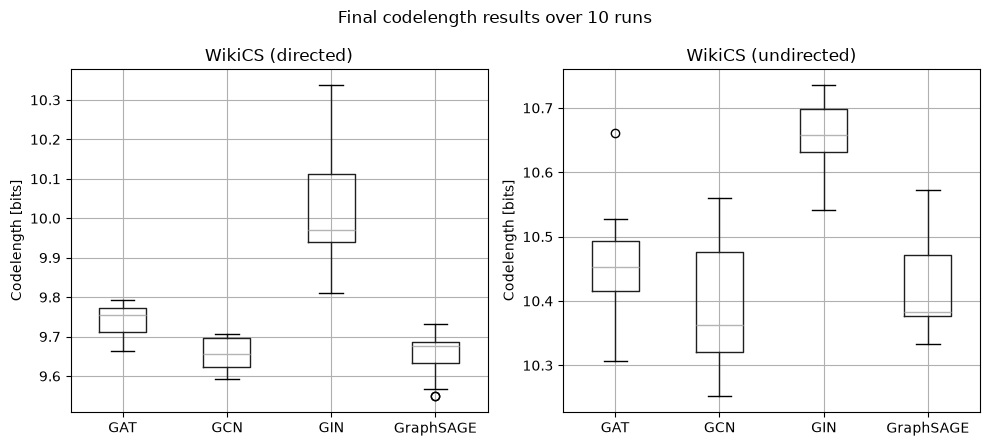

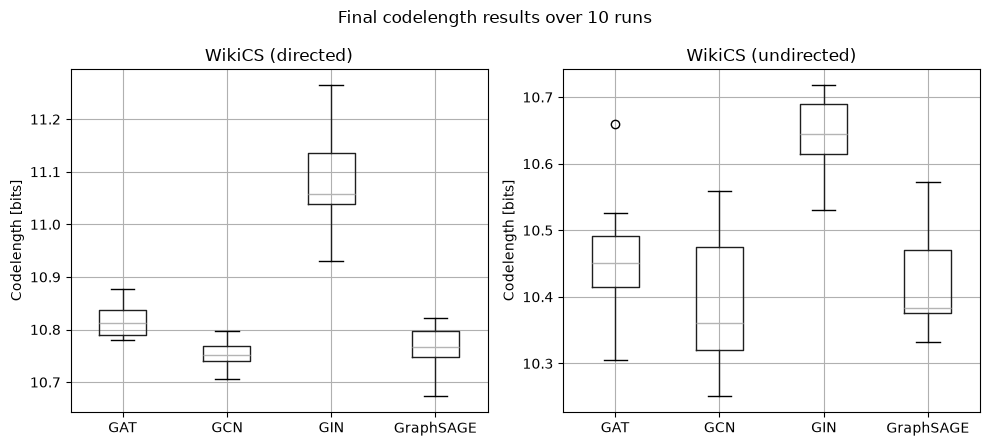

In [10]:
for metric in ["final_loss", "codelength_recomputed"]:

    fig, axes = plt.subplots(1, 2, figsize=(5*2, 4.5))
    for ax, variant in zip(axes, ["directed", "undirected"]):
        subset = neuromap_df[neuromap_df["variant"] == variant]
        if len(subset) == 0:
            continue
        subset.boxplot(column=metric, by="architecture", ax=ax)
        ax.set_title(f"WikiCS ({variant})")
        ax.set_xlabel("")
        ax.set_ylabel("Codelength [bits]")

    fig.suptitle(f"Final codelength results over 10 runs")
    fig.tight_layout()
    fig.savefig(f"../results/neuromap_stats_{metric}.png", dpi=500)
    plt.show()


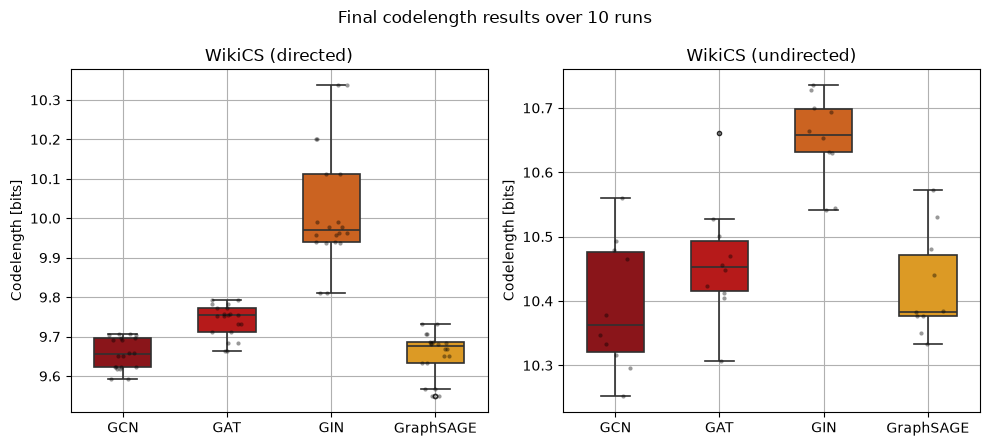

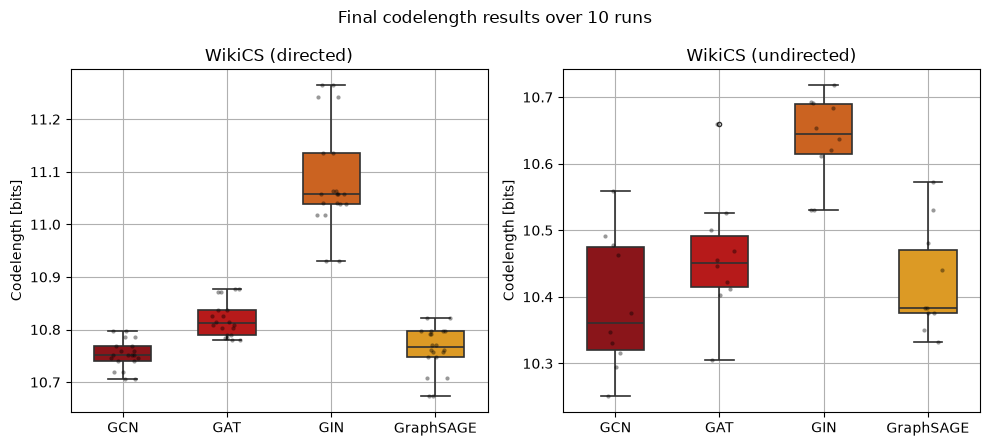

In [11]:
NEUROMAP_ARCHS = ["GCN", "GAT", "GIN", "GraphSAGE"]
NEUROMAP_COLORS = {
    "GCN": "#9d0208",
    "GAT": "#d00000",
    "GIN": "#e85d04",
    "GraphSAGE": "#faa307",
}

for metric in ["final_loss", "codelength_recomputed"]:

    fig, axes = plt.subplots(1, 2, figsize=(5*2, 4.5))
    for ax, variant in zip(axes, ["directed", "undirected"]):
        subset = neuromap_df[neuromap_df["variant"] == variant]
        if len(subset) == 0:
            continue
        sns.boxplot(
            data=subset, x="architecture", y=metric,
            hue="architecture", palette=NEUROMAP_COLORS,
            order=NEUROMAP_ARCHS, legend=False,
            width=0.55, linewidth=1.2, fliersize=3,
            ax=ax,
        )
        sns.stripplot(
            data=subset, x="architecture", y=metric,
            color="black", alpha=0.4, size=3, jitter=0.15,
            ax=ax,
        )
        ax.set_title(f"WikiCS ({variant})")
        ax.set_xlabel("")
        ax.set_ylabel("Codelength [bits]")
        ax.grid()

    fig.suptitle(f"Final codelength results over 10 runs")
    fig.tight_layout()
    fig.savefig(f"../results/neuromap_stats_{metric}.png", dpi=500)
    plt.show()

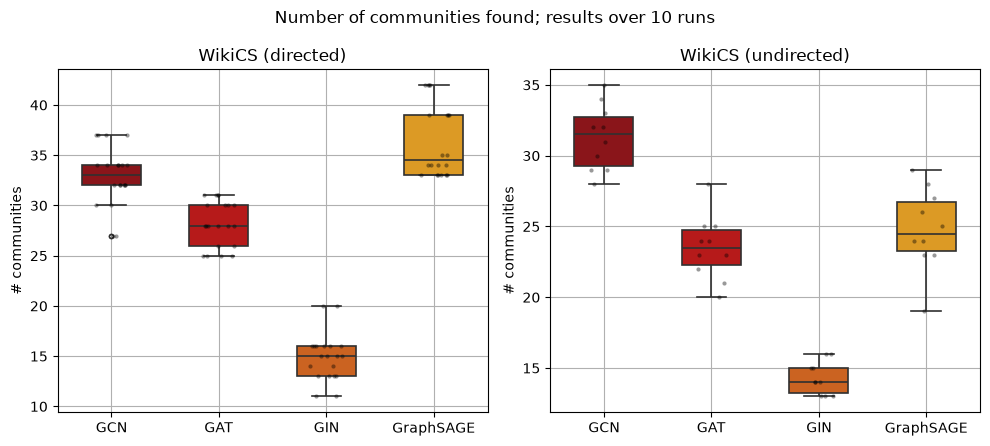

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(5*2, 4.5))
for ax, variant in zip(axes, ["directed", "undirected"]):
    subset = neuromap_df[neuromap_df["variant"] == variant]
    if len(subset) == 0:
        continue
    sns.boxplot(
        data=subset, x="architecture", y="num_comms",
        hue="architecture", palette=NEUROMAP_COLORS,
        order=NEUROMAP_ARCHS, legend=False,
        width=0.55, linewidth=1.2, fliersize=3,
        ax=ax,
    )
    sns.stripplot(
        data=subset, x="architecture", y="num_comms",
        color="black", alpha=0.4, size=3, jitter=0.15,
        ax=ax,
    )
    ax.set_title(f"WikiCS ({variant})")
    ax.set_xlabel("")
    ax.set_ylabel("# communities")
    ax.grid()

fig.suptitle(f"Number of communities found; results over 10 runs")
fig.tight_layout()
fig.savefig(f"../results/neuromap_stats_{metric}.png", dpi=500)
plt.show()

GCN: lengths range 802-1000 epochs; truncating.
GIN: lengths range 771-1000 epochs; truncating.


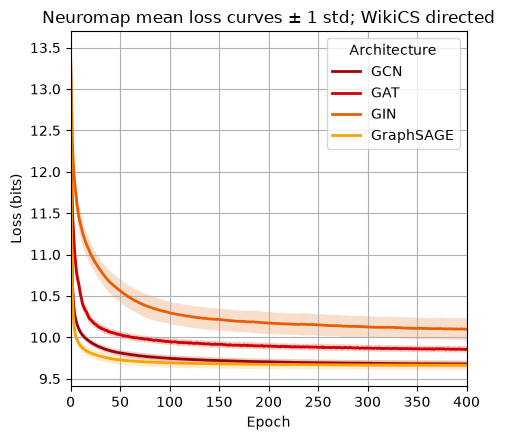

GIN: lengths range 325-1000 epochs; truncating.


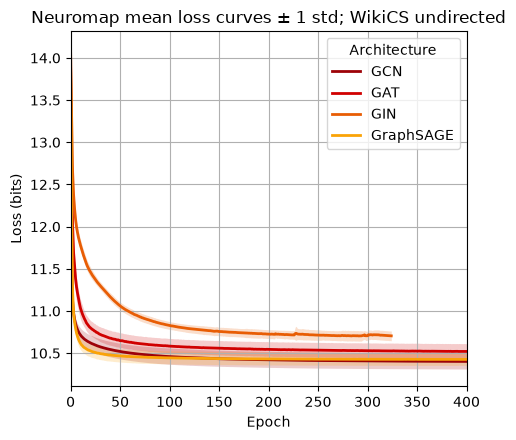

In [13]:
for variant in VARIANTS:
    fig, ax = plt.subplots(figsize=(5, 4.5))

    for arch in NEUROMAP_ARCHS:
        # load the curves
        rows = neuromap_df[(neuromap_df["variant"] == variant) & (neuromap_df["architecture"] == arch)]
        curves = []
        for _, row in rows.iterrows():
            curve = load_neuromap_loss_curve(f"../{row['loss_curve_file']}")
            curves.append(curve)

        if not curves:
            print(f"  [warn] no loss curves for variant={variant}, arch={arch}; skipping")
            continue

        # truncating to shortest so their lengths match
        lengths = [len(c) for c in curves]
        min_len = min(lengths)
        max_len = max(lengths)
        if max_len > min_len:
            print(f"{arch}: lengths range {min_len}-{max_len} epochs; truncating.")

        stacked= np.array([c[:min_len] for c in curves])
        
        mean_curve = np.nanmean(stacked, axis=0)
        std_curve = np.nanstd(stacked, axis=0)
        epochs = np.arange(len(mean_curve))

        color = NEUROMAP_COLORS[arch]
        ax.plot(epochs, mean_curve, label=arch, color=color, linewidth=2)
        ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=color, alpha=0.2, linewidth=0)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (bits)")
    ax.set_xlim(0, 400)
    ax.set_title(f"Neuromap mean loss curves ± 1 std; WikiCS {variant}")
    ax.legend(title="Architecture", frameon=True)
    ax.grid()
    fig.tight_layout()

    out_path = f"../results/loss_curves_mean_{variant}.png"
    fig.savefig(out_path, dpi=500)
    plt.show()

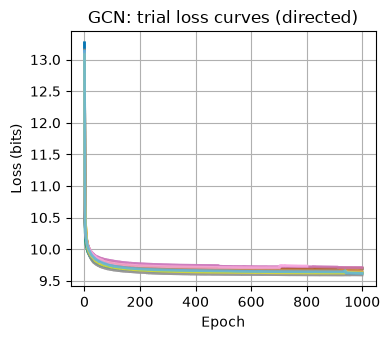

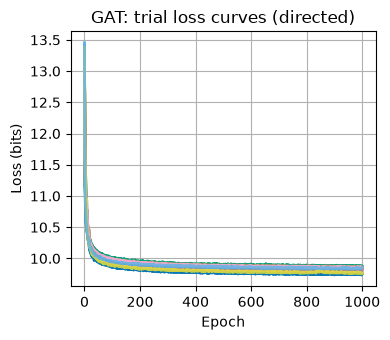

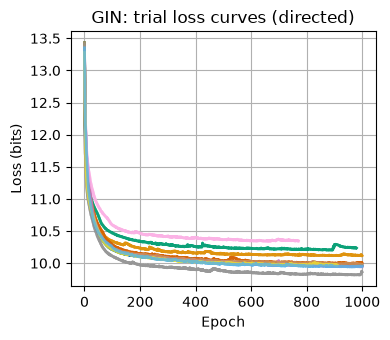

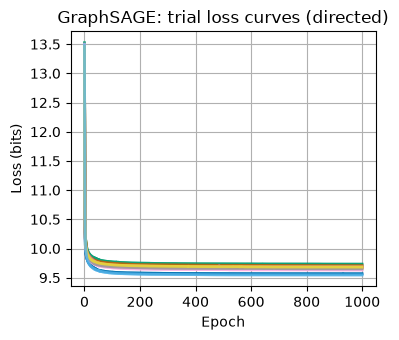

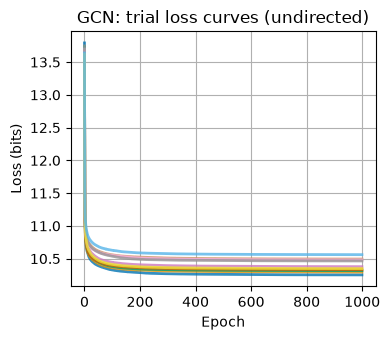

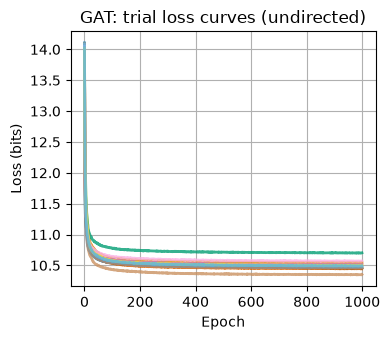

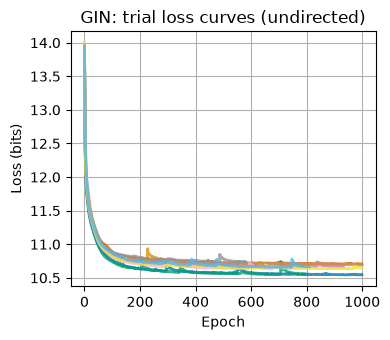

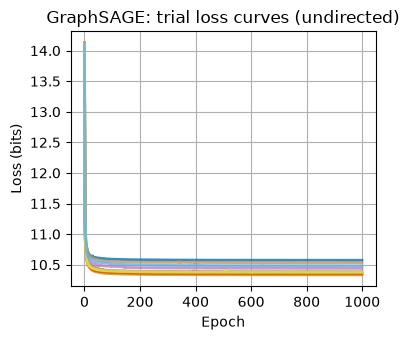

In [14]:
for variant in VARIANTS:
    for arch in NEUROMAP_ARCHS:
        rows = neuromap_df[(neuromap_df["variant"] == variant) & (neuromap_df["architecture"] == arch)]

        fig, ax = plt.subplots(figsize=(4, 3.5))
        palette = sns.color_palette("colorblind", n_colors=len(rows))

        for color, (_, row) in zip(palette, rows.iterrows()):
            data = load_json(f"../{row['loss_curve_file']}")
            if data is None:
                continue
            curve = data["loss_curve"]
            ax.plot(np.arange(len(curve)), curve, color=color, alpha=0.8,
                        linewidth=2, label=f"rerun {int(row['rerun']):02d}")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss (bits)")
        ax.grid()
        ax.set_title(f"{arch}: trial loss curves ({variant})")
        #ax.legend(title="Rerun", fontsize=8, ncol=2, frameon=True)
        #sns.despine(fig=fig)
        fig.tight_layout()

        out_path = f"../results/loss_curves_trials_{arch}_{variant}.png"
        fig.savefig(out_path, dpi=500)
        plt.show()

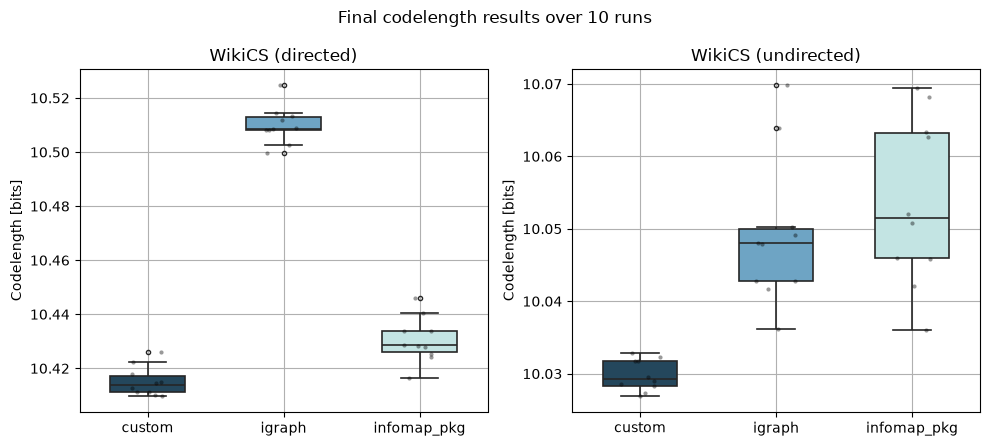

In [15]:
infomap_df = load_infomap_aggregated()

for metric in ["codelength_recomputed"]:

    fig, axes = plt.subplots(1, 2, figsize=(5*2, 4.5))
    for ax, variant in zip(axes, ["directed", "undirected"]):
        subset = infomap_df[infomap_df["variant"] == variant]
        if len(subset) == 0:
            continue
        sns.boxplot(
            data=subset, x="method", y=metric,
            hue="method", palette=INFOMAP_COLORS,
            order=INFOMAP_METHODS, legend=False,
            width=0.55, linewidth=1.2, fliersize=3,
            ax=ax,
        )
        sns.stripplot(
            data=subset, x="method", y=metric,
            color="black", alpha=0.4, size=3, jitter=0.15,
            ax=ax,
        )
        ax.set_title(f"WikiCS ({variant})")
        ax.set_xlabel("")
        ax.set_ylabel("Codelength [bits]")
        ax.grid()

    fig.suptitle(f"Final codelength results over 10 runs")
    fig.tight_layout()
    fig.savefig(f"../results/infomap_stats_{metric}.png", dpi=500)
    plt.show()

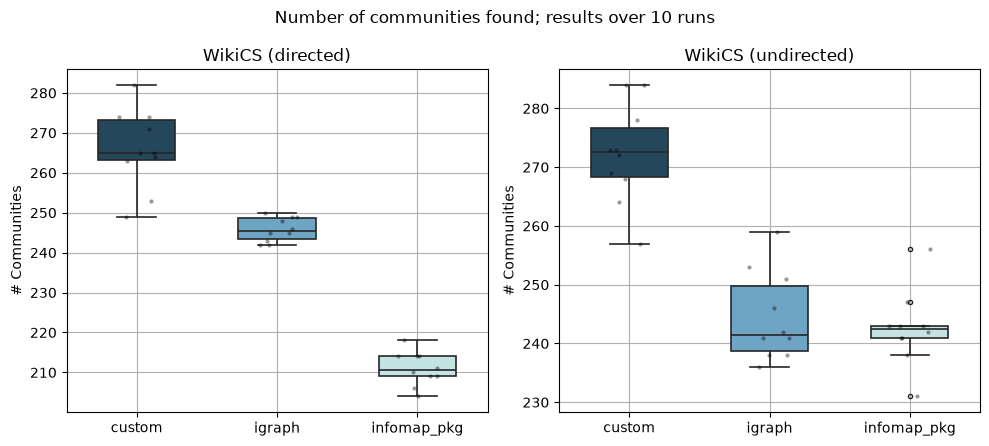

In [16]:
for metric in ["num_communities"]:

    fig, axes = plt.subplots(1, 2, figsize=(5*2, 4.5))
    for ax, variant in zip(axes, ["directed", "undirected"]):
        subset = infomap_df[infomap_df["variant"] == variant]
        if len(subset) == 0:
            continue
        sns.boxplot(
            data=subset, x="method", y=metric,
            hue="method", palette=INFOMAP_COLORS,
            order=INFOMAP_METHODS, legend=False,
            width=0.55, linewidth=1.2, fliersize=3,
            ax=ax,
        )
        sns.stripplot(
            data=subset, x="method", y=metric,
            color="black", alpha=0.4, size=3, jitter=0.15,
            ax=ax,
        )
        ax.set_title(f"WikiCS ({variant})")
        ax.set_xlabel("")
        ax.set_ylabel("# Communities")
        ax.grid()

    fig.suptitle(f"Number of communities found; results over 10 runs")
    fig.tight_layout()
    fig.savefig(f"../results/infomap_stats_{metric}.png", dpi=500)
    plt.show()

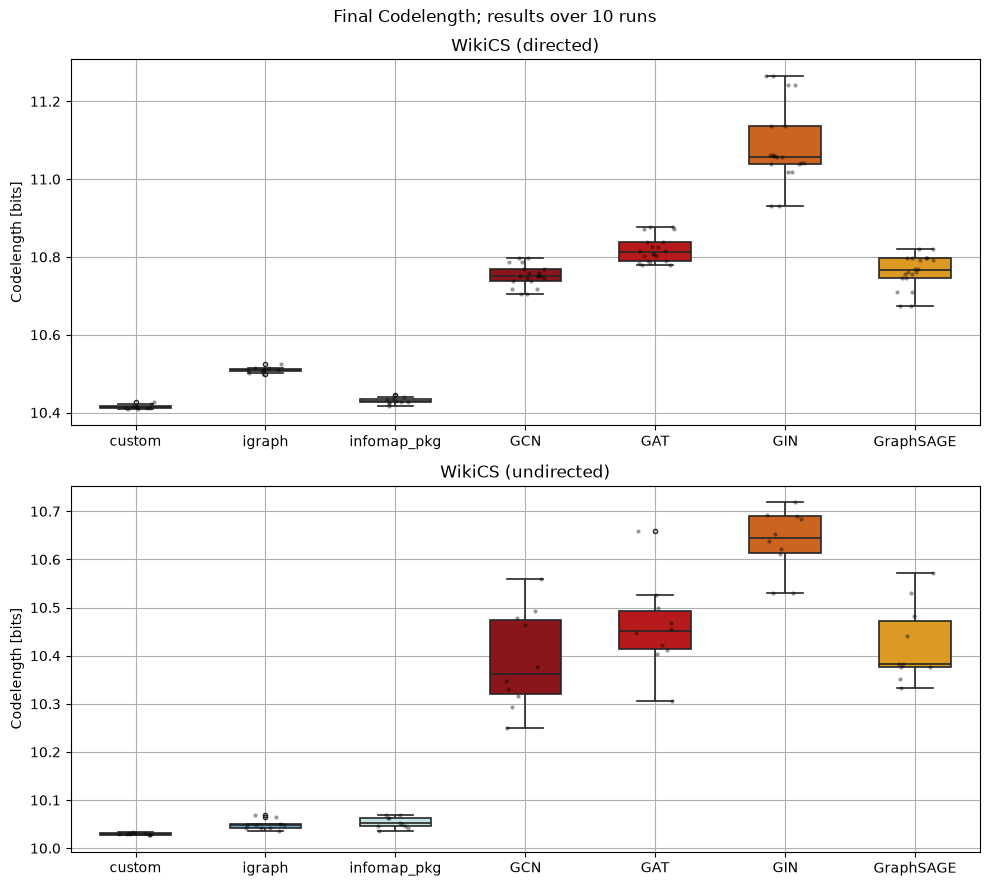

In [18]:
df_combined = load_combined(full=True)

for metric in ["codelength_recomputed"]:

    fig, axes = plt.subplots(2, 1, figsize=(10, 4.5*2))
    for ax, variant in zip(axes, ["directed", "undirected"]):
        subset = df_combined[df_combined["variant"] == variant]
        if len(subset) == 0:
            continue
        sns.boxplot(
            data=subset, x="method", y=metric,
            hue="method", palette=COLORS,
            order=METHODS, legend=False,
            width=0.55, linewidth=1.2, fliersize=3,
            ax=ax,
        )
        sns.stripplot(
            data=subset, x="method", y=metric,
            color="black", alpha=0.4, size=3, jitter=0.15,
            ax=ax,
        )
        ax.set_title(f"WikiCS ({variant})")
        ax.set_xlabel("")
        ax.set_ylabel("Codelength [bits]")
        ax.grid()

    fig.suptitle(f"Final Codelength; results over 10 runs")
    fig.tight_layout()
    fig.savefig(f"../results/full_stats_{metric}.png", dpi=500)
    plt.show()

## Comparing partitions

We have to obtain the ground truth community assigmnents for the WikiCS dataset, and make sure that the mapping to the nodes is preserved over us taking the LCC etc. 

In [19]:
true_comms = { "directed": G_directed.vs["community"],
              "undirected": G_undirected.vs["community"]
}

In [20]:
print("Ground truth community assignment:")
print("directed: L = ", meq.compute_description_length(graphs["directed"], true_comms["directed"]))
print("undirected: L = ", meq.compute_description_length(graphs["undirected"], true_comms["undirected"]))

Ground truth community assignment:
directed: L =  11.60892247923126
undirected: L =  11.59111193259665


Let's load the best partitions for each method

In [21]:
best_partitions = load_all_best_comms()

Comparing to the respective ground truth, computing the NMI, AMI, ARI:

In [22]:
partition_comp = []
for variant in VARIANTS:
    for method in METHODS:
        comms = best_partitions[(variant, method)]
        nmi, ami, ari = compare_partitions(comms, true_comms[variant])
        L = meq.compute_description_length(graphs[variant], comms)
        partition_comp.append({
            "variant": variant,
            "method": method,
            "codelength": L,
            "nmi": nmi,
            "ami": ami,
            "ari": ari
        })

partition_df = pd.DataFrame(partition_comp)

In [23]:
partition_df

,variant,method,codelength,nmi,ami,ari
0,directed,custom,10.409638,0.428832,0.406009,0.132773
1,directed,igraph,10.499791,0.432384,0.410951,0.132604
2,directed,infomap_pkg,10.416591,0.431825,0.413220,0.147052
3,directed,GCN,10.705553,0.456924,0.452898,0.295602
4,directed,GAT,10.780580,0.485147,0.481958,0.407907
5,directed,GIN,10.930380,0.438486,0.436089,0.346953
6,directed,GraphSAGE,10.672962,0.464510,0.460147,0.265695
7,undirected,custom,10.026865,0.415177,0.396010,0.156521
8,undirected,igraph,10.036233,0.416894,0.399650,0.163765
9,undirected,infomap_pkg,10.036054,0.414161,0.396949,0.158867


Pairwise comparison with each other:

In [24]:
best_partitions[("directed", "ground truth")] = true_comms["directed"]
best_partitions[("undirected", "ground truth")] = true_comms["undirected"]

In [25]:
import itertools
COMP_METRICS=["NMI", "AMI", "ARI"]
COMP_METHODS= METHODS + ["ground truth"]

def plot_partition_similarity(partitions: dict[tuple[str, str], list[int]]):
    """
    For each variant and each metric (AMI/NMI/ARI), builds the full pairwise
    similarity matrix across all methods that have a partition for that
    variant, and saves it as a heatmap.
    """
    for variant in VARIANTS:
        n = len(COMP_METHODS)
        nmi_g = np.full((n, n), np.nan)
        ami_g = np.full((n, n), np.nan)
        ari_g = np.full((n, n), np.nan)

        for i, j in itertools.product(range(n), range(n)):
            m_i, m_j = COMP_METHODS[i], COMP_METHODS[j]
            part_i = partitions[(variant, m_i)]
            part_j = partitions[(variant, m_j)]
            nmi, ami, ari  = compare_partitions(part_i, part_j, print_results=False)
            nmi_g[i, j] = nmi                 
            ami_g[i, j] = ami
            ari_g[i, j] = ari

        for k, matrix in enumerate([nmi_g, ami_g, ari_g]):
            fig, ax = plt.subplots(figsize=(0.6 * n + 2, 0.6 * n + 1.5))
            im = ax.imshow(matrix, vmin=0, vmax=1, cmap="viridis")
            ax.set_xticks(range(n))
            ax.set_yticks(range(n))
            ax.set_xticklabels(COMP_METHODS, rotation=45, ha="right", fontsize=14)
            ax.set_yticklabels(COMP_METHODS, fontsize=14)
            for i, j in itertools.product(range(n), range(n)):
                if not np.isnan(matrix[i, j]):
                    ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                            color="white" if matrix[i, j] < 0.6 else "black", fontsize=14)
            ax.set_title(f"Pairwise {COMP_METRICS[k]} comparison (WikiCS {variant})", fontsize=16)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=14)
            fig.tight_layout()

            out_path = f"../results/partition_comp_{COMP_METRICS[k].lower()}_{variant}.png"
            fig.savefig(out_path, dpi=500)
            plt.show()


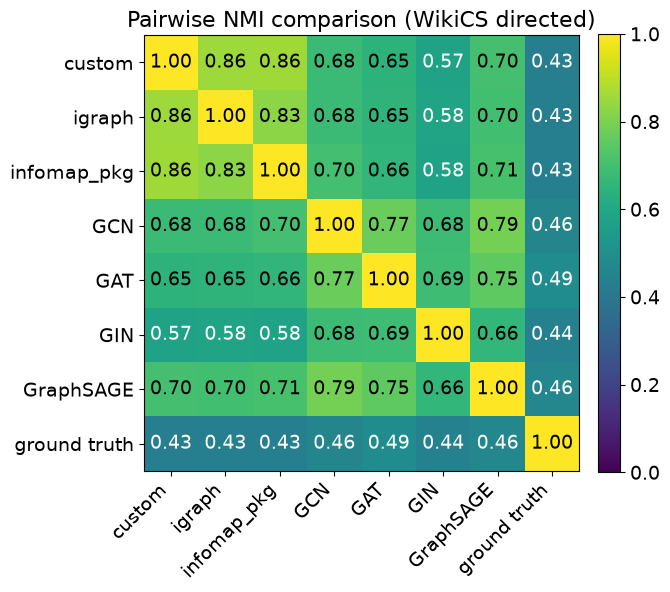

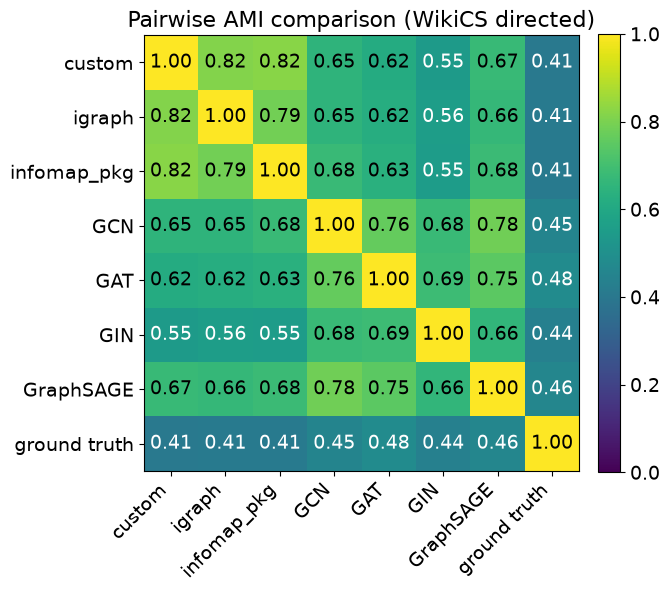

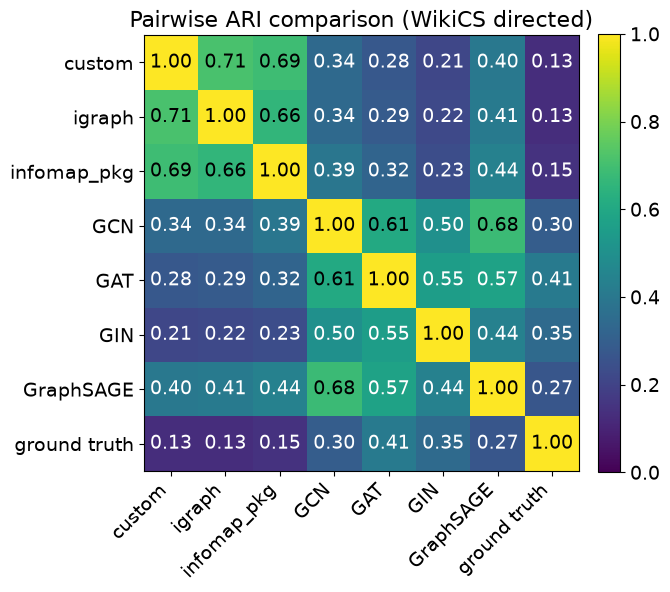

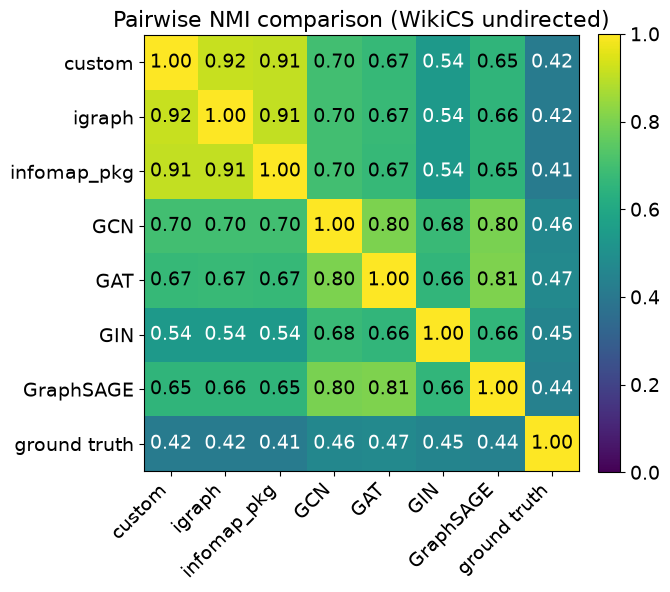

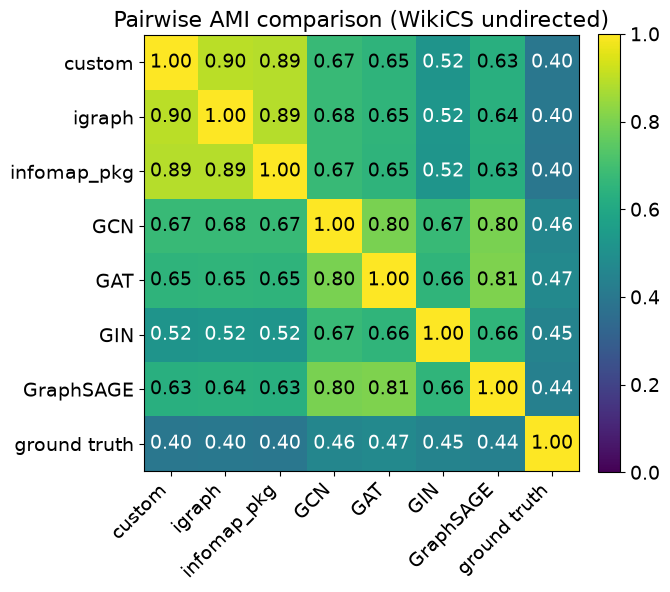

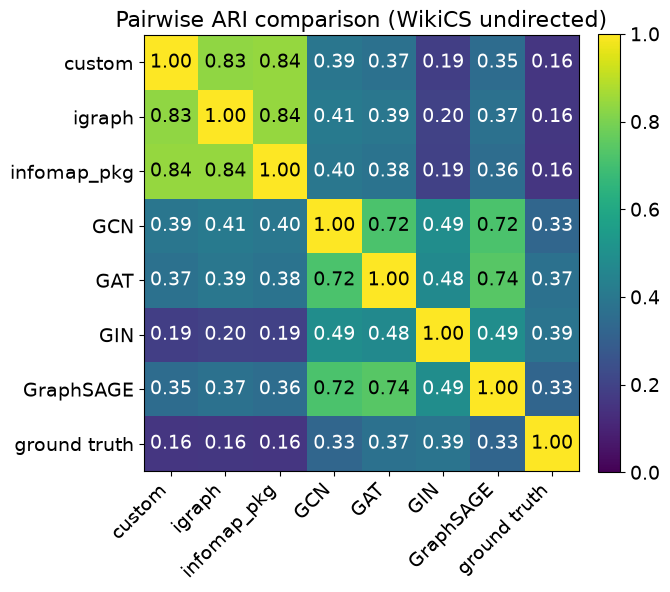

In [26]:
plot_partition_similarity(best_partitions)